# Thoracic Disease Classifier ResNet-50 Architecture (Existing Algo)

Install Dependencies

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import load_model
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import glob

Split data for training and validation dataset 

In [2]:
# Dataset paths
BASE_DIR = "./dataset_balanced/"
CSV_PATH = os.path.join(BASE_DIR, "new_labels.csv")
IMAGE_DIR = os.path.join(BASE_DIR, "new_images", "new_images")

# Verify paths exist
if not os.path.exists(CSV_PATH):
    print(f"CSV file not found at: {CSV_PATH}")
if not os.path.exists(IMAGE_DIR):
    print(f"Image directory not found at: {IMAGE_DIR}")

# Get image files
IMAGE_FILES = {os.path.basename(f): f for f in glob.glob(os.path.join(IMAGE_DIR, "*.png"))}
print(f"Total images found: {len(IMAGE_FILES)}")

Total images found: 51382


In [3]:
# Load CSV
df = pd.read_csv(CSV_PATH)
print(f"CSV shape: {df.shape}")
print(f"CSV columns: {df.columns.tolist()}")
print("\nFirst few rows of the CSV:")
print(df.head())

# Check what columns exist and map them appropriately
image_col = None
label_cols = []

# Common variations for image column names
image_col_variants = ['Image Index', 'Path', 'image_path', 'filename', 'image_name', 'image']
for variant in image_col_variants:
    if variant in df.columns:
        image_col = variant
        break

if image_col is None:
    print("ERROR: No image path column found. Available columns:", df.columns.tolist())
    print("Please check your CSV file structure.")
    raise ValueError("Image path column not found")

print(f"Using '{image_col}' as image path column")

# Check if this is a multi-label format (one column with pipe-separated values)
# or multi-column format (separate columns for each disease)
label_col_variants = ['Finding Labels', 'Labels', 'findings', 'diseases', 'pathology']
single_label_col = None

for variant in label_col_variants:
    if variant in df.columns:
        single_label_col = variant
        break

if single_label_col is not None:
    print(f"Found single label column: '{single_label_col}'")
    # Keep only relevant columns and rename for consistency
    df = df[[image_col, single_label_col]].copy()
    df.columns = ['Image Index', 'Finding Labels']
else:
    # Check if we have individual disease columns (typical thoracic disease column names)
    disease_columns = [
        'Atelectasis', 'Consolidation', 'Infiltration', 'Pneumothorax', 
        'Edema', 'Emphysema', 'Fibrosis', 'Effusion', 'Pneumonia', 
        'Pleural_Thickening', 'Cardiomegaly', 'Nodule', 'Mass', 
        'Hernia', 'No Finding'
    ]
    
    # Find which disease columns exist in our CSV
    available_disease_cols = [col for col in disease_columns if col in df.columns]
    
    if len(available_disease_cols) > 0:
        print(f"Found individual disease columns: {available_disease_cols}")
        
        # Create a combined label column from individual disease columns
        def create_combined_labels(row):
            diseases = []
            for col in available_disease_cols:
                if row[col] == 1:  # Assuming binary encoding (0/1)
                    diseases.append(col)
            return '|'.join(diseases) if diseases else 'No Finding'
        
        df['Finding Labels'] = df.apply(create_combined_labels, axis=1)
        
        # Keep only image column and the new combined labels
        df = df[[image_col, 'Finding Labels']].copy()
        df.columns = ['Image Index', 'Finding Labels']
        
    else:
        print("ERROR: No label columns found.")
        print("Available columns:", df.columns.tolist())
        print("\nExpected either:")
        print("1. A single column with pipe-separated labels (e.g., 'Finding Labels', 'Labels')")
        print("2. Individual binary columns for each disease (e.g., 'Pneumonia', 'Atelectasis')")
        raise ValueError("No suitable label columns found")

print(f"\nFinal DataFrame structure:")
print(f"Columns: {df.columns.tolist()}")
print(f"Shape: {df.shape}")
print("\nSample data:")
print(df.head())

# Convert multi-labels into lists
df['Finding Labels'] = df['Finding Labels'].apply(lambda x: x.split('|') if isinstance(x, str) else [])

# Filter only images that exist in the image directory
df_filtered = df[df['Image Index'].isin(IMAGE_FILES.keys())].copy()
print(f"Images after filtering: {len(df_filtered)}")

if len(df_filtered) == 0:
    print("No matching images found! Check if image names in CSV match actual image files.")
    print("Sample CSV image names:", df['Image Index'].head().tolist())
    print("Sample actual image files:", list(IMAGE_FILES.keys())[:5])

# Binarize the labels
mlb = MultiLabelBinarizer()
binarized_labels = mlb.fit_transform(df_filtered['Finding Labels'])

# Convert binarized labels into a DataFrame with column names
valid_labels = mlb.classes_
print(f"Valid labels: {valid_labels}")

label_columns = valid_labels
df_labels = pd.DataFrame(binarized_labels, columns=label_columns)

# Concatenate with the original DataFrame
df_filtered = pd.concat([df_filtered[['Image Index']], df_labels], axis=1)

# Check label distribution
print("Label distribution:")
print(df_labels.sum(axis=0))

CSV shape: (51382, 16)
CSV columns: ['Path', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'No Finding', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

First few rows of the CSV:
               Path  Atelectasis  Cardiomegaly  Consolidation  Edema  \
0  00000001_000.png            0             1              0      0   
1  00000001_001.png            0             1              0      0   
2  00000001_002.png            0             1              0      0   
3  00000002_000.png            0             0              0      0   
4  00000003_000.png            0             0              0      0   

   Effusion  Emphysema  Fibrosis  Hernia  Infiltration  Mass  No Finding  \
0         0          0         0       0             0     0           0   
1         0          1         0       0             0     0           0   
2         1          0         0       0             0     0   

In [4]:
# Display some examples
print("\nSample data:")
print(df_filtered.head())


Sample data:
        Image Index  Atelectasis  Cardiomegaly  Consolidation  Edema  \
0  00000001_000.png            0             1              0      0   
1  00000001_001.png            0             1              0      0   
2  00000001_002.png            0             1              0      0   
3  00000002_000.png            0             0              0      0   
4  00000003_000.png            0             0              0      0   

   Effusion  Emphysema  Fibrosis  Hernia  Infiltration  Mass  No Finding  \
0         0          0         0       0             0     0           0   
1         0          1         0       0             0     0           0   
2         1          0         0       0             0     0           0   
3         0          0         0       0             0     0           1   
4         0          0         0       1             0     0           0   

   Nodule  Pleural_Thickening  Pneumonia  Pneumothorax  
0       0                   0          

In [5]:
# Check for Pneumonia examples
pneumonia_examples = df[df['Finding Labels'].apply(lambda x: 'Pneumonia' in x)]
print(f"\nPneumonia examples found: {len(pneumonia_examples)}")
print(pneumonia_examples.head())


Pneumonia examples found: 6105
          Image Index       Finding Labels
88   00000056_000.png  [Pneumonia, Nodule]
93   00000061_015.png          [Pneumonia]
203  00000144_001.png          [Pneumonia]
216  00000165_001.png          [Pneumonia]
257  00000193_019.png          [Pneumonia]


In [6]:
# Show label combinations
print("\nLabel combinations:")
if 'Finding Labels' in df_filtered.columns:
    label_combinations = df_filtered['Finding Labels'].apply(lambda x: x if isinstance(x, str) else ','.join(x) if isinstance(x, list) else str(x))
    print(label_combinations.value_counts().head(10))
else:
    # If Finding Labels column is not available, create it from the binary columns
    def get_label_combination(row):
        active_labels = [col for col in valid_labels if row[col] == 1]
        return ','.join(active_labels) if active_labels else 'No Finding'
    
    label_combinations = df_filtered.apply(get_label_combination, axis=1)
    print(label_combinations.value_counts().head(10))


Label combinations:
No Finding            5000
Hernia                2970
Nodule                2705
Infiltration          2389
Cardiomegaly          2287
Pneumothorax          2194
Fibrosis              2181
Mass                  2139
Pneumonia             1932
Pleural_Thickening    1820
Name: count, dtype: int64


Load Dataset and Split

In [7]:
# Prepare input (X) and labels (y)
X = df_filtered['Image Index'].values  # Image filenames
y = df_filtered[valid_labels].values   # Multi-label one-hot encoding

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=None  # Remove stratify for multilabel
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=None
)

print(f"Train samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

# Create DataFrames for generators
train_df = pd.DataFrame({'Image Index': X_train})
train_df = pd.concat([train_df, pd.DataFrame(y_train, columns=valid_labels)], axis=1)

val_df = pd.DataFrame({'Image Index': X_val})
val_df = pd.concat([val_df, pd.DataFrame(y_val, columns=valid_labels)], axis=1)

test_df = pd.DataFrame({'Image Index': X_test})
test_df = pd.concat([test_df, pd.DataFrame(y_test, columns=valid_labels)], axis=1)

Train samples: 36994
Validation samples: 4111
Test samples: 10277


In [8]:
# Augmentation settings for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20, 
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# No augmentation for validation/test (only rescale)
val_test_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Train generator with augmentation
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=IMAGE_DIR,  # Correct path to images
    x_col="Image Index",
    y_col=list(valid_labels),  # Convert to list
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True
)

# Validation generator (no augmentation)
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=IMAGE_DIR,  # Correct path to images
    x_col="Image Index",
    y_col=list(valid_labels),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

# Test generator (for final evaluation)
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory=IMAGE_DIR,  # Correct path to images
    x_col="Image Index",
    y_col=list(valid_labels),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

print("Data generators created successfully!")

Found 36994 validated image filenames.
Found 4111 validated image filenames.
Found 10277 validated image filenames.
Data generators created successfully!


Load ResNet-50 from ImageNet and re-train Classification Head

In [9]:
# Load ResNet-50 with pretrained weights
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze all convolutional layers
for layer in base_model.layers:
    layer.trainable = False

# Add new classification head
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x_class = Dense(128, activation='relu')(x)
x_class = Dropout(0.3)(x_class)
output_class = Dense(len(valid_labels), activation='sigmoid', name='classification_output')(x_class)

# Define and compile model
model = Model(inputs=base_model.input, outputs=output_class)
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy', 'AUC']
)

print("Model created and compiled!")
print(f"Model will predict {len(valid_labels)} classes: {valid_labels}")

# Callbacks
checkpoint = ModelCheckpoint(
    'classification_head.h5', 
    monitor='val_auc', 
    mode='max', 
    save_best_only=True, 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=2, 
    verbose=1, 
    min_lr=1e-6
)

callbacks = [checkpoint, reduce_lr]

# Train the classification head only
print("Starting initial training (frozen base model)...")
history = model.fit(
    train_generator,
    epochs=5,  
    validation_data=val_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    callbacks=callbacks,
    verbose=1
)

Model created and compiled!
Model will predict 15 classes: ['Atelectasis' 'Cardiomegaly' 'Consolidation' 'Edema' 'Effusion'
 'Emphysema' 'Fibrosis' 'Hernia' 'Infiltration' 'Mass' 'No Finding'
 'Nodule' 'Pleural_Thickening' 'Pneumonia' 'Pneumothorax']
Starting initial training (frozen base model)...
Epoch 1/5
1157/1157 [==============================] - ETA: 0s - loss: 0.3618 - accuracy: 0.0684 - auc: 0.5076
Epoch 1: val_auc improved from -inf to 0.55495, saving model to classification_head.h5
1157/1157 [==============================] - 1813s 2s/step - loss: 0.3618 - accuracy: 0.0684 - auc: 0.5076 - val_loss: 0.3202 - val_accuracy: 0.0805 - val_auc: 0.5549 - lr: 1.0000e-04
Epoch 2/5
1157/1157 [==============================] - ETA: 0s - loss: 0.3345 - accuracy: 0.0693 - auc: 0.5220
Epoch 2: val_auc improved from 0.55495 to 0.57952, saving model to classification_head.h5
1157/1157 [==============================] - 1498s 1s/step - loss: 0.3345 - accuracy: 0.0693 - auc: 0.5220 - val_loss

Unfreezing the Last 10 Layers for Transfer Learning

In [10]:
# Unfreeze last 10 layers of ResNet-50 for fine-tuning
print("Unfreezing last 10 layers for fine-tuning...")
for layer in base_model.layers[-10:]:
    layer.trainable = True

finetune_checkpoint = ModelCheckpoint(
    'baseline_resnet50.h5', 
    monitor='val_auc', 
    mode='max', 
    save_best_only=True, 
    verbose=1
)
finetune_callbacks = [finetune_checkpoint, reduce_lr]

# Recompile with a smaller learning rate for fine-tuning
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-5),  # Lower LR for fine-tuning
    metrics=['accuracy', 'AUC']
)

# Fine-tuning
print("Starting fine-tuning...")
history_finetune = model.fit(
    train_generator,
    epochs=5, 
    validation_data=val_generator,
    steps_per_epoch=len(train_generator),
    validation_steps=len(val_generator),
    callbacks=finetune_callbacks,
    verbose=1
)

Unfreezing last 10 layers for fine-tuning...
Starting fine-tuning...
Epoch 1/5
1157/1157 [==============================] - ETA: 0s - loss: 0.3164 - accuracy: 0.1085 - auc: 0.6113
Epoch 1: val_auc improved from -inf to 0.67753, saving model to baseline_resnet50.h5
1157/1157 [==============================] - 1238s 1s/step - loss: 0.3164 - accuracy: 0.1085 - auc: 0.6113 - val_loss: 0.3039 - val_accuracy: 0.1352 - val_auc: 0.6775 - lr: 1.0000e-05
Epoch 2/5
1157/1157 [==============================] - ETA: 0s - loss: 0.3111 - accuracy: 0.1259 - auc: 0.6382
Epoch 2: val_auc improved from 0.67753 to 0.69392, saving model to baseline_resnet50.h5
1157/1157 [==============================] - 2086s 2s/step - loss: 0.3111 - accuracy: 0.1259 - auc: 0.6382 - val_loss: 0.2998 - val_accuracy: 0.1678 - val_auc: 0.6939 - lr: 1.0000e-05
Epoch 3/5
1157/1157 [==============================] - ETA: 0s - loss: 0.3090 - accuracy: 0.1366 - auc: 0.6488
Epoch 3: val_auc improved from 0.69392 to 0.69935, saving

Testing the Model

In [11]:
# Load the best model
print("Loading best model...")
model = load_model('baseline_resnet50.h5')

Loading best model...


Testing prediction...
1/1 [==============================] - 1s 985ms/step


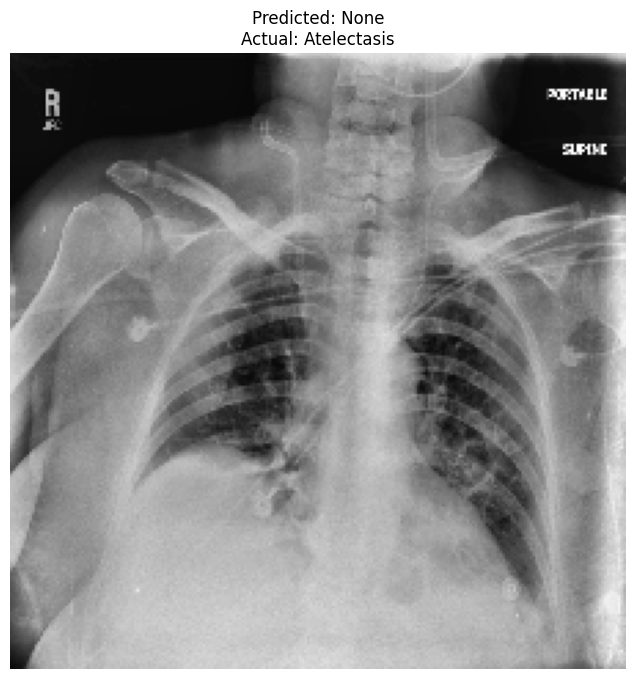

In [12]:
# Test prediction on a batch
print("Testing prediction...")
test_generator.reset()  # Reset generator to start from beginning
batch_images, batch_labels = next(iter(test_generator))

# Predict on the batch
batch_preds = model.predict(batch_images)

# Choose a random image from the batch
idx = np.random.randint(len(batch_images))
img = batch_images[idx]
true_label = batch_labels[idx]
pred_label = (batch_preds[idx] > 0.19).astype(int)  # Threshold for prediction

# Convert one-hot encoded labels back to class names
true_label_names = [valid_labels[i] for i in range(len(valid_labels)) if true_label[i] == 1]
pred_label_names = [valid_labels[i] for i in range(len(valid_labels)) if pred_label[i] == 1]

# Remove "No Finding" if there are other predicted labels
if "No Finding" in pred_label_names and len(pred_label_names) > 1:
    pred_label_names.remove("No Finding")

# Show the image
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis('off')
plt.title(f"Predicted: {', '.join(pred_label_names) if pred_label_names else 'None'}\nActual: {', '.join(true_label_names) if true_label_names else 'None'}")
plt.show()

Save the Model

In [13]:
# Save models
print("Saving models...")
model.save('baseline_model_resnet50.h5')  # Fixed typo in filename
model.save('baseline_model_resnet50.keras')

Saving models...


Evaluation

Evaluating on test set...
322/322 [==============================] - 345s 1s/step


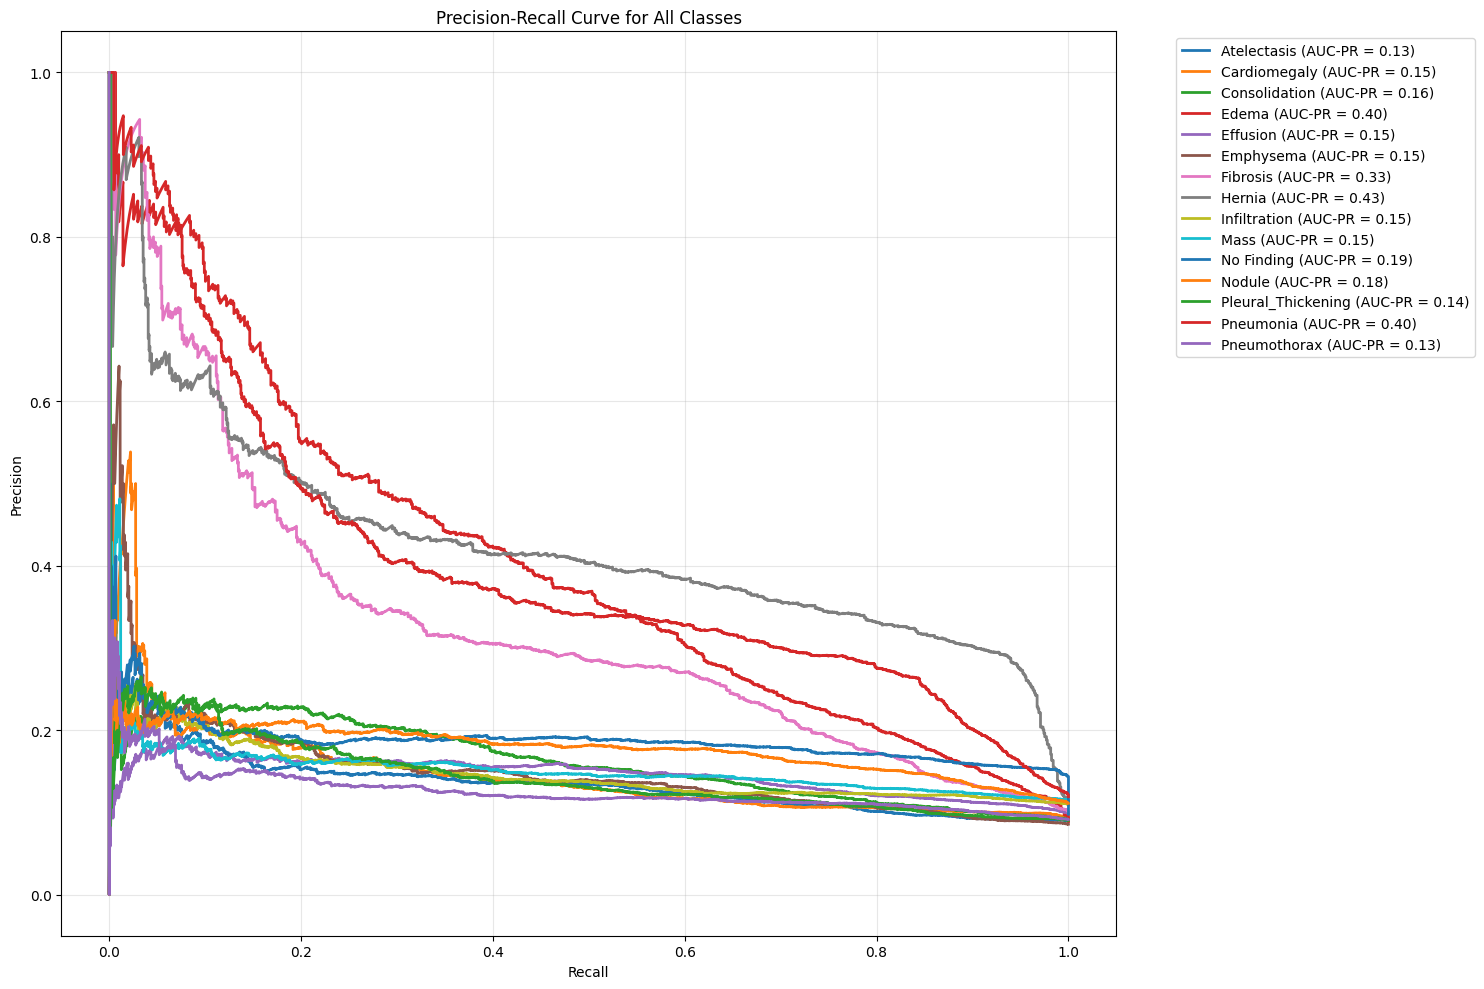


Model Training Complete!
Classes: 15
Training samples: 36994
Validation samples: 4111
Test samples: 10277

AUC-PR scores by class:
Atelectasis: 0.135
Cardiomegaly: 0.148
Consolidation: 0.162
Edema: 0.399
Effusion: 0.145
Emphysema: 0.149
Fibrosis: 0.328
Hernia: 0.425
Infiltration: 0.147
Mass: 0.152
No Finding: 0.187
Nodule: 0.177
Pleural_Thickening: 0.144
Pneumonia: 0.398
Pneumothorax: 0.125

Mean AUC-PR: 0.215


In [14]:
print("Evaluating on test set...")
# Reset test generator for full evaluation
test_generator.reset()

# Predict probabilities for test set
y_pred = model.predict(test_generator, verbose=1)

# Ensure we have the correct number of predictions
if len(y_pred) != len(y_test):
    print(f"Warning: Prediction length ({len(y_pred)}) doesn't match test length ({len(y_test)})")
    # Truncate to minimum length
    min_len = min(len(y_pred), len(y_test))
    y_pred = y_pred[:min_len]
    y_test_eval = y_test[:min_len]
else:
    y_test_eval = y_test

# Compute Precision-Recall and AUC-PR for each class
precision = dict()
recall = dict()
auc_pr = dict()

for i in range(len(valid_labels)):
    precision[i], recall[i], _ = precision_recall_curve(y_test_eval[:, i], y_pred[:, i])
    auc_pr[i] = auc(recall[i], precision[i])

# Plot Precision-Recall curve for each class
plt.figure(figsize=(15, 10))
for i in range(len(valid_labels)):
    plt.plot(recall[i], precision[i], lw=2, label=f'{valid_labels[i]} (AUC-PR = {auc_pr[i]:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for All Classes')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\nModel Training Complete!")
print(f"Classes: {len(valid_labels)}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")
print("\nAUC-PR scores by class:")
for i, label in enumerate(valid_labels):
    print(f"{label}: {auc_pr[i]:.3f}")

print(f"\nMean AUC-PR: {np.mean(list(auc_pr.values())):.3f}")